primer modelo de inicio


In [ ]:
import subprocess

# Installation on Google Colab
try:
    import google.colab
    subprocess.run(['python', '-m', 'pip', 'install', 'skorch' , 'torch'])
except ImportError:
    pass

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

In [ ]:
torch.manual_seed(0)
torch.cuda.manual_seed(0)

In [ ]:
import pandas as pd
import numpy as np

df_186= pd.read_csv('experiment_186.tsv', sep = '\t')

df_186.head(100)


,id,molecule_id,name,formula,rt,smiles.std,inchi.std,inchikey.std,classyfire.kingdom,classyfire.superclass,...,C [%]_16,D [%]_16,flow rate [ml/min]_16,t [min]_17,A [%]_17,B [%]_17,C [%]_17,D [%]_17,flow rate [ml/min]_17,fingerprint
0,186,0186_00001,NaN,C3H8N2S,1.558333,CCSC(=N)N,"InChI=1S/C3H8N2S/c1-2-6-3(4)5/h2H2,1H3,(H3,4,5)",VFIZBHJTOHUOEK-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Organosulfur compounds (CHEMONTID:0000004),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,186,0186_00002,NaN,C19H25Cl2N3O3,11.463333,COC(=O)N1CCN(C(C1)CN2CCCC2)C(=O)CC3=CC(=C(C=C3...,InChI=1S/C19H25Cl2N3O3/c1-27-19(26)23-8-9-24(1...,HJUAKZYKCANOOZ-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Benzenoids (CHEMONTID:0002448),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,186,0186_00003,NaN,C17H27N3O4S,9.845000,CCN1CCCC1CNC(=O)C2=CC(=C(C=C2OC)N)S(=O)(=O)CC,InChI=1S/C17H27N3O4S/c1-4-20-8-6-7-12(20)11-19...,NTJOBXMMWNYJFB-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Benzenoids (CHEMONTID:0002448),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,186,0186_00004,NaN,C9H7NO2,9.726667,C1=CC2=C(C=CNC2=O)C(=C1)O,InChI=1S/C9H7NO2/c11-8-3-1-2-7-6(8)4-5-10-9(7)...,LFUJIPVWTMGYDG-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Organoheterocyclic compounds (CHEMONTID:0000002),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,186,0186_00005,NaN,C15H20N2O2,9.650000,C1CN(CCC12CNC(=O)O2)CCC3=CC=CC=C3,InChI=1S/C15H20N2O2/c18-14-16-12-15(19-14)7-10...,FVNFBBAOMBJTST-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Organoheterocyclic compounds (CHEMONTID:0000002),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,186,0186_00096,NaN,C23H26FN3O2,12.088333,C1CN(CCC12C(=O)NCN2C3=CC=CC=C3)CCCC(=O)C4=CC=C...,InChI=1S/C23H26FN3O2/c24-19-10-8-18(9-11-19)21...,DKGZKTPJOSAWFA-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Organic oxygen compounds (CHEMONTID:0004603),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
96,186,0186_00097,NaN,C6H11NO,8.123333,CC1(CCC=[N+]1[O-])C,"InChI=1S/C6H11NO/c1-6(2)4-3-5-7(6)8/h5H,3-4H2,...",VCUVETGKTILCLC-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Organoheterocyclic compounds (CHEMONTID:0000002),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
97,186,0186_00098,NaN,C21H29NO4,11.136667,CN(CCC1=CC(=C(C=C1)OC)OC)CCC2=CC(=C(C=C2)OC)OC,InChI=1S/C21H29NO4/c1-22(12-10-16-6-8-18(23-2)...,OXZMQFKVNVQMLI-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Benzenoids (CHEMONTID:0002448),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
98,186,0186_00099,NaN,C20H24N2OS,12.866667,CCC(=O)C1=CC2=C(C=C1)SC3=CC=CC=C3N2CCCN(C)C,InChI=1S/C20H24N2OS/c1-4-18(23)15-10-11-20-17(...,ZQTVCQIJTREKSP-UHFFFAOYSA-N,Organic compounds (CHEMONTID:0000000),Organoheterocyclic compounds (CHEMONTID:0000002),...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
import json
df_186["fingerprint"] = df_186["fingerprint"].apply(
    lambda x: np.array(json.loads(x), dtype=np.float32)
)

analisis de dataset original y creacion de datos de entrenamiento

In [ ]:

datos_186 = df_186[["rt", "fingerprint"]].copy()

print(datos_186.head())

          rt                                        fingerprint
0   1.558333  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1  11.463333  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2   9.845000  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
3   9.726667  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4   9.650000  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...


In [ ]:
df_186["rt"].describe()

,rt
count,83738.000000
mean,13.091164
std,3.493489
min,0.005000
25%,10.965000
50%,12.825000
75%,15.145000
max,24.528333


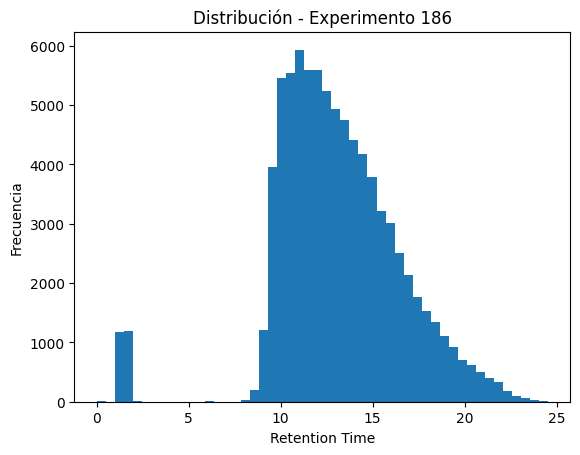

In [ ]:
import matplotlib.pyplot as plt
rt= df_186["rt"]
plt.hist(rt, bins=50)
plt.xlabel("Retention Time")
plt.ylabel("Frecuencia")
plt.title("Distribución - Experimento 186")
plt.show()

In [ ]:
print(type(datos_186["fingerprint"].iloc[0]))
print(datos_186["fingerprint"].iloc[0])

<class 'numpy.ndarray'>
[0. 0. 0. ... 0. 0. 0.]


In [ ]:
X_186 = np.stack(datos_186["fingerprint"].values).astype(np.float32)
y_186 = datos_186["rt"].values.astype(np.float32)

print(X_186.shape)
print(y_186.shape)

(83738, 2048)
(83738,)


In [ ]:
print("Número de moléculas del experimento 186:", len(df_186))
print("Shape de X:", X_186.shape)
print("Shape de y:", y_186.shape)
print("Primer rt:", y_186[0])
print("Primer fingerprint:", X_186[0][:20])

Número de moléculas del experimento 186: 83738
Shape de X: (83738, 2048)
Shape de y: (83738,)
Primer rt: 1.5583333
Primer fingerprint: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Division de dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = X_186
y = y_186

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (58616, 2048) (58616,)
Val: (12561, 2048) (12561,)
Test: (12561, 2048) (12561,)


Noarmalizacion y conversion a tensores

In [ ]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).astype(np.float32)
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).astype(np.float32)
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).astype(np.float32)

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

In [ ]:
print(X_train_t.shape)
print(X_test_t.shape)
print(X_val_t.shape)
print(y_train_t.shape)
print(y_test_t.shape)
print(y_val_t.shape)

torch.Size([58616, 2048])
torch.Size([12561, 2048])
torch.Size([12561, 2048])
torch.Size([58616, 1])
torch.Size([12561, 1])
torch.Size([12561, 1])


In [ ]:
import torch.nn as nn


class RetentionTimeNN001_Dropout(nn.Module):
    def __init__(self, input_dim=2048):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
model = RetentionTimeNN001_Dropout(input_dim=X.shape[1])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Entrenamiento

In [ ]:
num_epochs = 150

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

for epoch in range(num_epochs):
    #entrenar
    model.train()
    y_train_pred = model(X_train_t)
    train_loss = criterion(y_train_pred, y_train_t)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    #validar
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_t)
        val_loss = criterion(y_val_pred, y_val_t)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

model.load_state_dict(best_model_state)

Epoch [10/150] | Train Loss: 0.4874 | Val Loss: 0.4705
Epoch [20/150] | Train Loss: 0.3416 | Val Loss: 0.3325
Epoch [30/150] | Train Loss: 0.2862 | Val Loss: 0.2914
Epoch [40/150] | Train Loss: 0.2377 | Val Loss: 0.2547
Epoch [50/150] | Train Loss: 0.1928 | Val Loss: 0.2259
Epoch [60/150] | Train Loss: 0.1550 | Val Loss: 0.2058
Epoch [70/150] | Train Loss: 0.1259 | Val Loss: 0.1936
Epoch [80/150] | Train Loss: 0.1082 | Val Loss: 0.1879
Epoch [90/150] | Train Loss: 0.0926 | Val Loss: 0.1844
Epoch [100/150] | Train Loss: 0.0798 | Val Loss: 0.1832
Epoch [110/150] | Train Loss: 0.0711 | Val Loss: 0.1816
Epoch [120/150] | Train Loss: 0.0637 | Val Loss: 0.1816
Epoch [130/150] | Train Loss: 0.0585 | Val Loss: 0.1823
Epoch [140/150] | Train Loss: 0.0552 | Val Loss: 0.1836
Epoch [150/150] | Train Loss: 0.0491 | Val Loss: 0.1819


<All keys matched successfully>

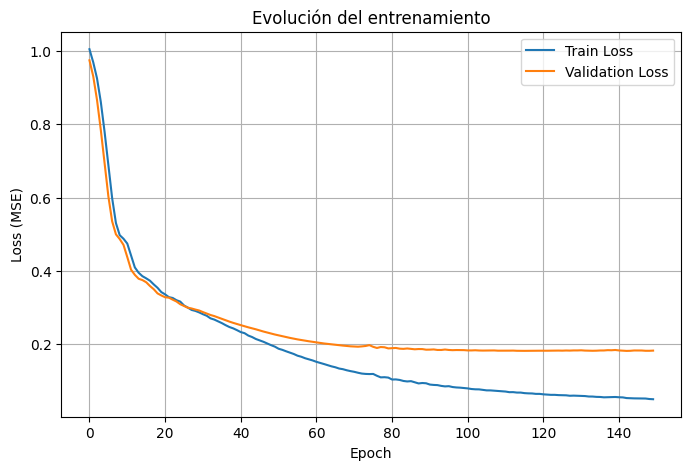

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Evolución del entrenamiento")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    y_test_pred_scaled = model(X_test_t).cpu().numpy()

y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled).flatten()
y_test_real = y_test

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
mae = mean_absolute_error(y_test_real, y_test_pred)
r2 = r2_score(y_test_real, y_test_pred)

print("\nResultados finales en TEST:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Resultados finales en TEST:
RMSE: 1.466210300073959
MAE: 0.8678127527236938
R2: 0.8226656317710876


In [ ]:

print("\nÚltima Train Loss:", train_losses[-1])
print("Última Val Loss:", val_losses[-1])
print("Mejor Val Loss:", best_val_loss)


Última Train Loss: 0.04909578710794449
Última Val Loss: 0.18185381591320038
Mejor Val Loss: 0.18107272684574127


In [ ]:
torch.save({
    "model_state_dict": best_model_state,
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_loss": best_val_loss,
    "train_losses": train_losses,
    "val_losses": val_losses
}, "checkpoint_mejor_modelo.pth")

In [ ]:
from google.colab import files
files.download("checkpoint_mejor_modelo.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>